# Final Corpus — Results

Aggregated classification results across all models, prompt versions and corpus types.

Metrics are derived automatically from the test CSVs and wrongly-classified CSVs produced by each batch notebook. Re-run this notebook after completing more runs to pick up new data.

## Dependencies

In [1]:
import os
import re

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix

%matplotlib inline
plt.style.use('../style.mplstyle')

## Configuration

In [2]:
VERSIONS = ["v1", "v2", "v3", "v4", "v5"]
MODELS   = ["gpt-5.4-mini", "gemini-3.1-pro"]

CORPUS_TYPES = {
    "raw-corpus":          "../data/raw/final-corpus/raw-corpus/standard/test.csv",
    "pre-filtered-corpus": "../data/raw/final-corpus/pre-filtered-corpus/standard/test.csv",
}

# Error CSV pattern saved by the batch notebooks
def error_csv_path(corpus_type, model, version):
    return f"../data/processed/final-corpus/{corpus_type}/wct_{model}-{version}.csv"

OUT_IMG_DIR = "../media/results/final-corpus"
os.makedirs(OUT_IMG_DIR, exist_ok=True)

## Prompt versions

In [3]:
PROMPTS = {
    "v1": """Clasifica cada tweet como POSITIVE o NEGATIVE según estos criterios:

POSITIVE: cumple con uno o más de los siguientes:
- El usuario del tweet habla de cómo o qué tipo de droga ilícita está consumiendo.
- El usuario del tweet expresa la necesidad de consumir drogas ilícitas, ya sea por abstinencia o por gusto.
- El usuario añora consumir drogas ilícitas.

NEGATIVE: no cumple con ningún criterio POSITIVE, por ejemplo:
- Habla sobre noticias o información general sobre drogas ilícitas.
- Menciona drogas ilícitas sin relación con consumo problemático o necesidad.
- Expresa ironía o sarcasmo relacionado con drogas ilícitas.""",

    "v2": """Clasifica cada tweet como POSITIVE o NEGATIVE según estos criterios:

POSITIVE: cumple con uno o más de los siguientes:
- El usuario del tweet habla de cómo o qué tipo de droga ilícita está consumiendo.
- El usuario del tweet expresa la necesidad de consumir drogas ilícitas, ya sea por abstinencia o por gusto.
- El usuario añora consumir drogas ilícitas.

NEGATIVE: no cumple con ningún criterio POSITIVE, por ejemplo:
- Habla sobre noticias o información general sobre drogas ilícitas.
- Menciona drogas ilícitas sin relación con consumo problemático o necesidad.
- Expresa ironía o sarcasmo relacionado con drogas ilícitas.

Tener en cuenta los siguientes aspectos:
- En el tweet puede estar presente la ironía o sarcasmo.
- El análisis se centra en el autor del tweet.
- Algunos tweets mencionan tomar una línea de colectivo, subte o tren, pero solamente esto no es condición suficiente para interpretarlo como una referencia al consumo de drogas ilícitas.""",

    "v3": """Clasifica cada tweet como POSITIVE o NEGATIVE según estos criterios:

POSITIVE: cumple con uno o más de los siguientes:
- El autor describe que está consumiendo o ha consumido drogas ilícitas, y lo presenta de forma neutral o positiva.
- El autor expresa deseo, necesidad o anhelo de consumir drogas ilícitas.
- El autor manifiesta nostalgia por experiencias pasadas de consumo de drogas ilícitas.

NEGATIVE: no cumple con ningún criterio POSITIVE, por ejemplo:
- El autor menciona consumo propio pero lo critica o desaprueba.
- Describe consumo de otra persona (real o ficticia).
- Usa humor, ironía o sarcasmo sin implicar deseo o nostalgia real de consumo propio.
- Menciona drogas ilícitas en contextos informativos, ficticios o metafóricos.
- Habla de transporte público (colectivo, subte, tren) sin relación clara con drogas ilícitas.

Consideraciones:
- El foco está en consumo problemático del autor, no solo en cualquier mención de consumo.
- Ante ambigüedad, clasificar como NEGATIVE.""",

    "v4": """Clasifica cada tweet como POSITIVE o NEGATIVE según estos criterios:

POSITIVE: cumple con uno o más de los siguientes:
- El autor indica explícitamente que consume o ha consumido drogas ilícitas y lo describe de forma neutral o positiva.
- El autor expresa deseo, necesidad o anhelo de consumir drogas ilícitas.
- El autor manifiesta nostalgia por consumo pasado, sin desaprobarlo.

NEGATIVE: no cumple con ningún criterio POSITIVE, por ejemplo:
- El autor menciona consumo propio pero lo desaprueba, lo critica o lo presenta como algo negativo.
- Contiene citas o menciones de consumo atribuibles a otra persona.
- Usa ironía, sarcasmo o lenguaje figurado sin implicar deseo o nostalgia real de consumo propio.
- Habla de drogas ilícitas en canciones, chistes, noticias o ficción.
- Usa expresiones como "tomar una línea" para referirse a transporte público, sin evidencia clara de drogas ilícitas.

Consideraciones:
- Si hay mezcla de experiencias propias y ajenas, clasificar como POSITIVE solo si el consumo problemático propio es explícito.
- Ante ambigüedad, clasificar como NEGATIVE.""",

    "v5": """Clasifica cada tweet como POSITIVE o NEGATIVE aplicando esta jerarquía de reglas:

1. Si el autor afirma explícitamente que consume, ha consumido o desea consumir drogas ilícitas, y lo expresa de manera neutral o positiva → POSITIVE.
2. Si el autor menciona consumo propio pero con desaprobación, crítica o rechazo → NEGATIVE.
3. Si describe consumo de otra persona, real o ficticia → NEGATIVE.
4. Si es ambiguo y puede interpretarse de forma no problemática → NEGATIVE.
5. Si menciona drogas ilícitas en contextos humorísticos, ficticios, metafóricos o musicales, sin expresar deseo o nostalgia propia → NEGATIVE.
6. Si menciona "tomar una línea" en contexto de transporte público → NEGATIVE.

Definiciones:
- "Neutral o positiva" significa que el autor no expresa desaprobación o condena.
- "Nostalgia" implica recordar consumo pasado con añoranza o valoración positiva.""",
}

## Derive metrics from CSVs

For each `(corpus_type, model, version)` combination, if the error CSV exists we reconstruct the full confusion matrix and compute precision / recall / F1 from the test CSV + error CSV.

In [4]:
LABELS = ["POSITIVE", "NEGATIVE"]

def derive_metrics(corpus_type, model, version):
    test_path  = CORPUS_TYPES[corpus_type]
    error_path = error_csv_path(corpus_type, model, version)

    if not os.path.exists(error_path):
        return None  # run not completed yet

    test_df  = pd.read_csv(test_path)
    error_df = pd.read_csv(error_path)

    # Reconstruct full prediction series:
    # all tweets start as correctly predicted, then override with errors
    pred = test_df["label"].copy()
    for _, row in error_df.iterrows():
        mask = (test_df["text"] == row["text"]) & (test_df["label"] == row["label"])
        pred[mask[mask].index] = row["prediction"]

    y_true = test_df["label"]
    y_pred = pred

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    report = classification_report(y_true, y_pred, labels=LABELS, output_dict=True)

    return {
        "corpus":        corpus_type,
        "model":         model,
        "version":       version,
        "label":         f"{version} | {model}",
        "accuracy":      report["accuracy"],
        "pos_precision": report["POSITIVE"]["precision"],
        "pos_recall":    report["POSITIVE"]["recall"],
        "pos_f1":        report["POSITIVE"]["f1-score"],
        "neg_precision": report["NEGATIVE"]["precision"],
        "neg_recall":    report["NEGATIVE"]["recall"],
        "neg_f1":        report["NEGATIVE"]["f1-score"],
        "fp":            int(cm[1, 0]),   # true NEG predicted POS
        "fn":            int(cm[0, 1]),   # true POS predicted NEG
        "total_wrong":   int(cm[0,1] + cm[1,0]),
        "cm":            cm.tolist(),
        "n_total":       len(test_df),
    }

all_results = []
for corpus_type in CORPUS_TYPES:
    for model in MODELS:
        for version in VERSIONS:
            result = derive_metrics(corpus_type, model, version)
            if result:
                all_results.append(result)
            else:
                print(f"  [skipped] {corpus_type} / {model} / {version} — error CSV not found")

print(f"\n{len(all_results)} run(s) loaded.")

  [skipped] raw-corpus / gemini-3.1-pro / v1 — error CSV not found
  [skipped] raw-corpus / gemini-3.1-pro / v2 — error CSV not found
  [skipped] raw-corpus / gemini-3.1-pro / v3 — error CSV not found
  [skipped] raw-corpus / gemini-3.1-pro / v4 — error CSV not found
  [skipped] raw-corpus / gemini-3.1-pro / v5 — error CSV not found


  [skipped] pre-filtered-corpus / gemini-3.1-pro / v1 — error CSV not found
  [skipped] pre-filtered-corpus / gemini-3.1-pro / v2 — error CSV not found
  [skipped] pre-filtered-corpus / gemini-3.1-pro / v3 — error CSV not found
  [skipped] pre-filtered-corpus / gemini-3.1-pro / v4 — error CSV not found
  [skipped] pre-filtered-corpus / gemini-3.1-pro / v5 — error CSV not found

10 run(s) loaded.


## Classification report heatmap

Separate heatmap per corpus type.

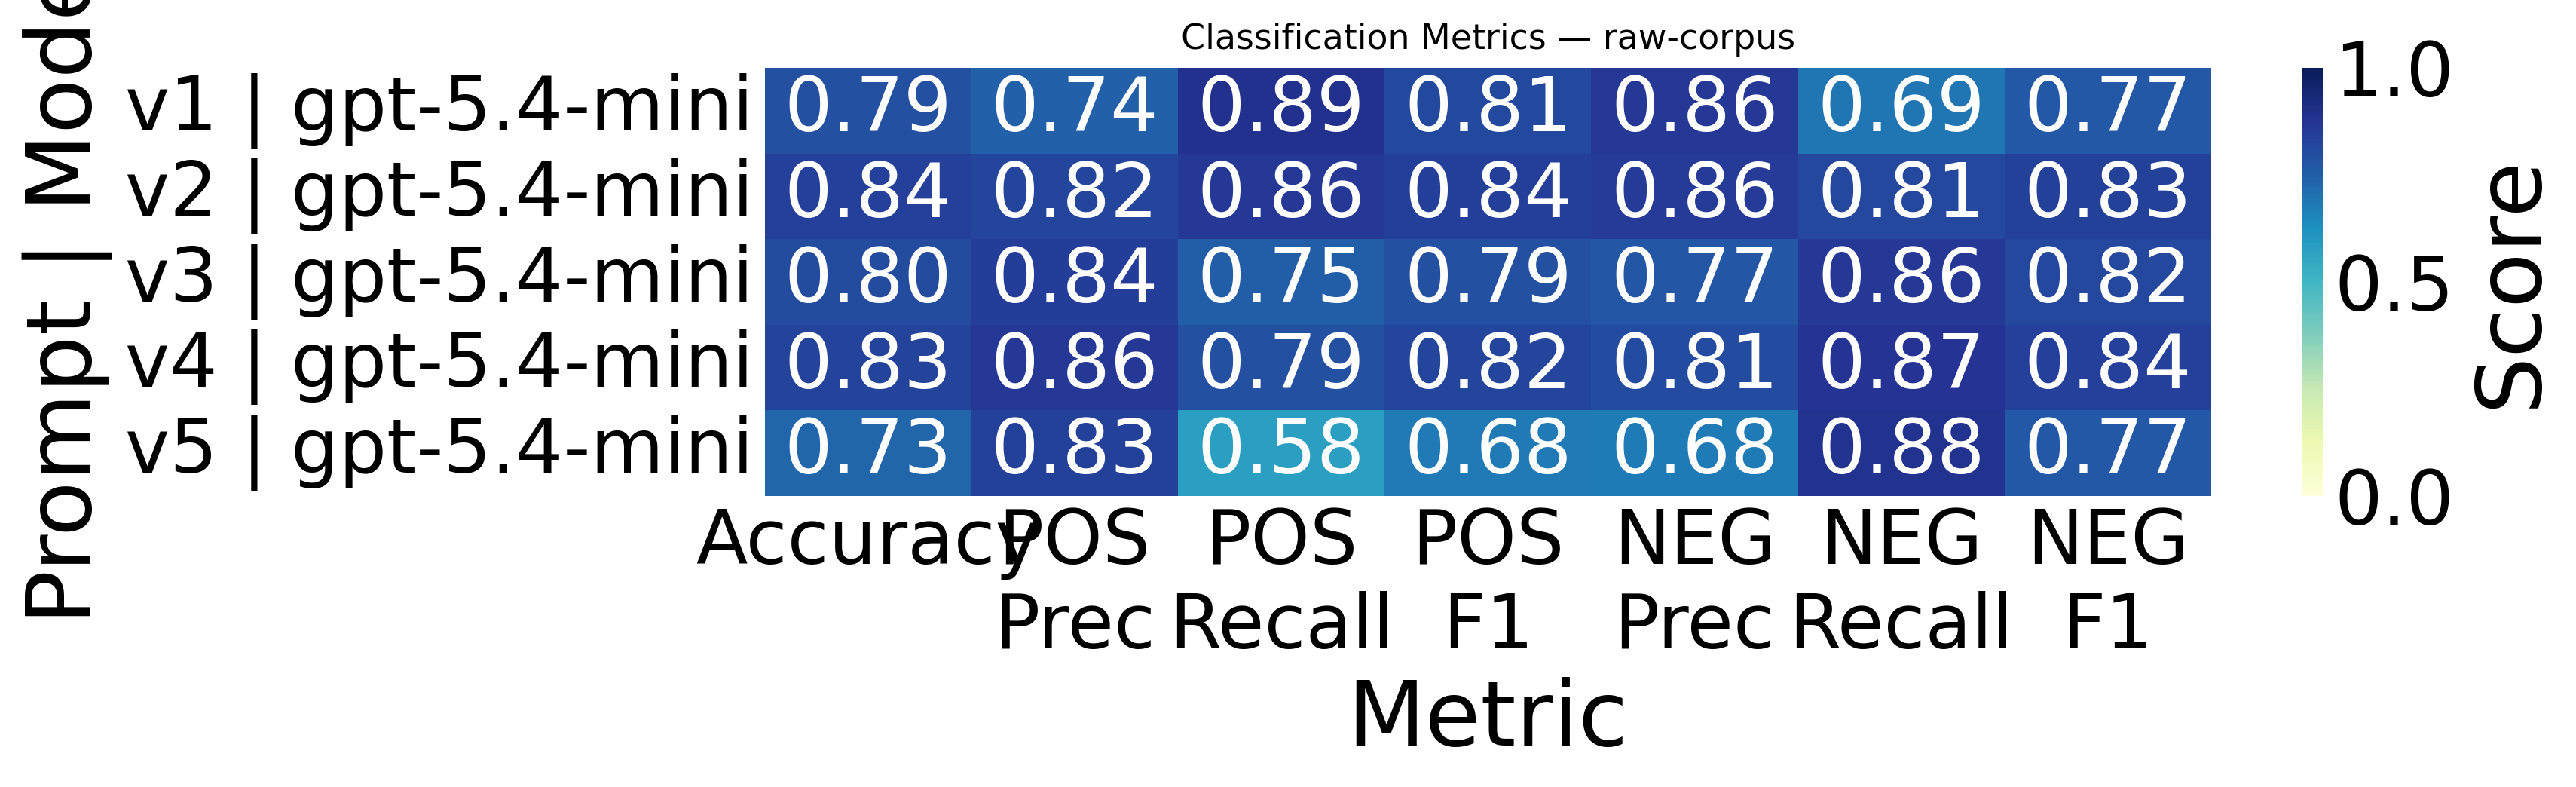

Saved → ../media/results/final-corpus/classification-report-raw-corpus.png


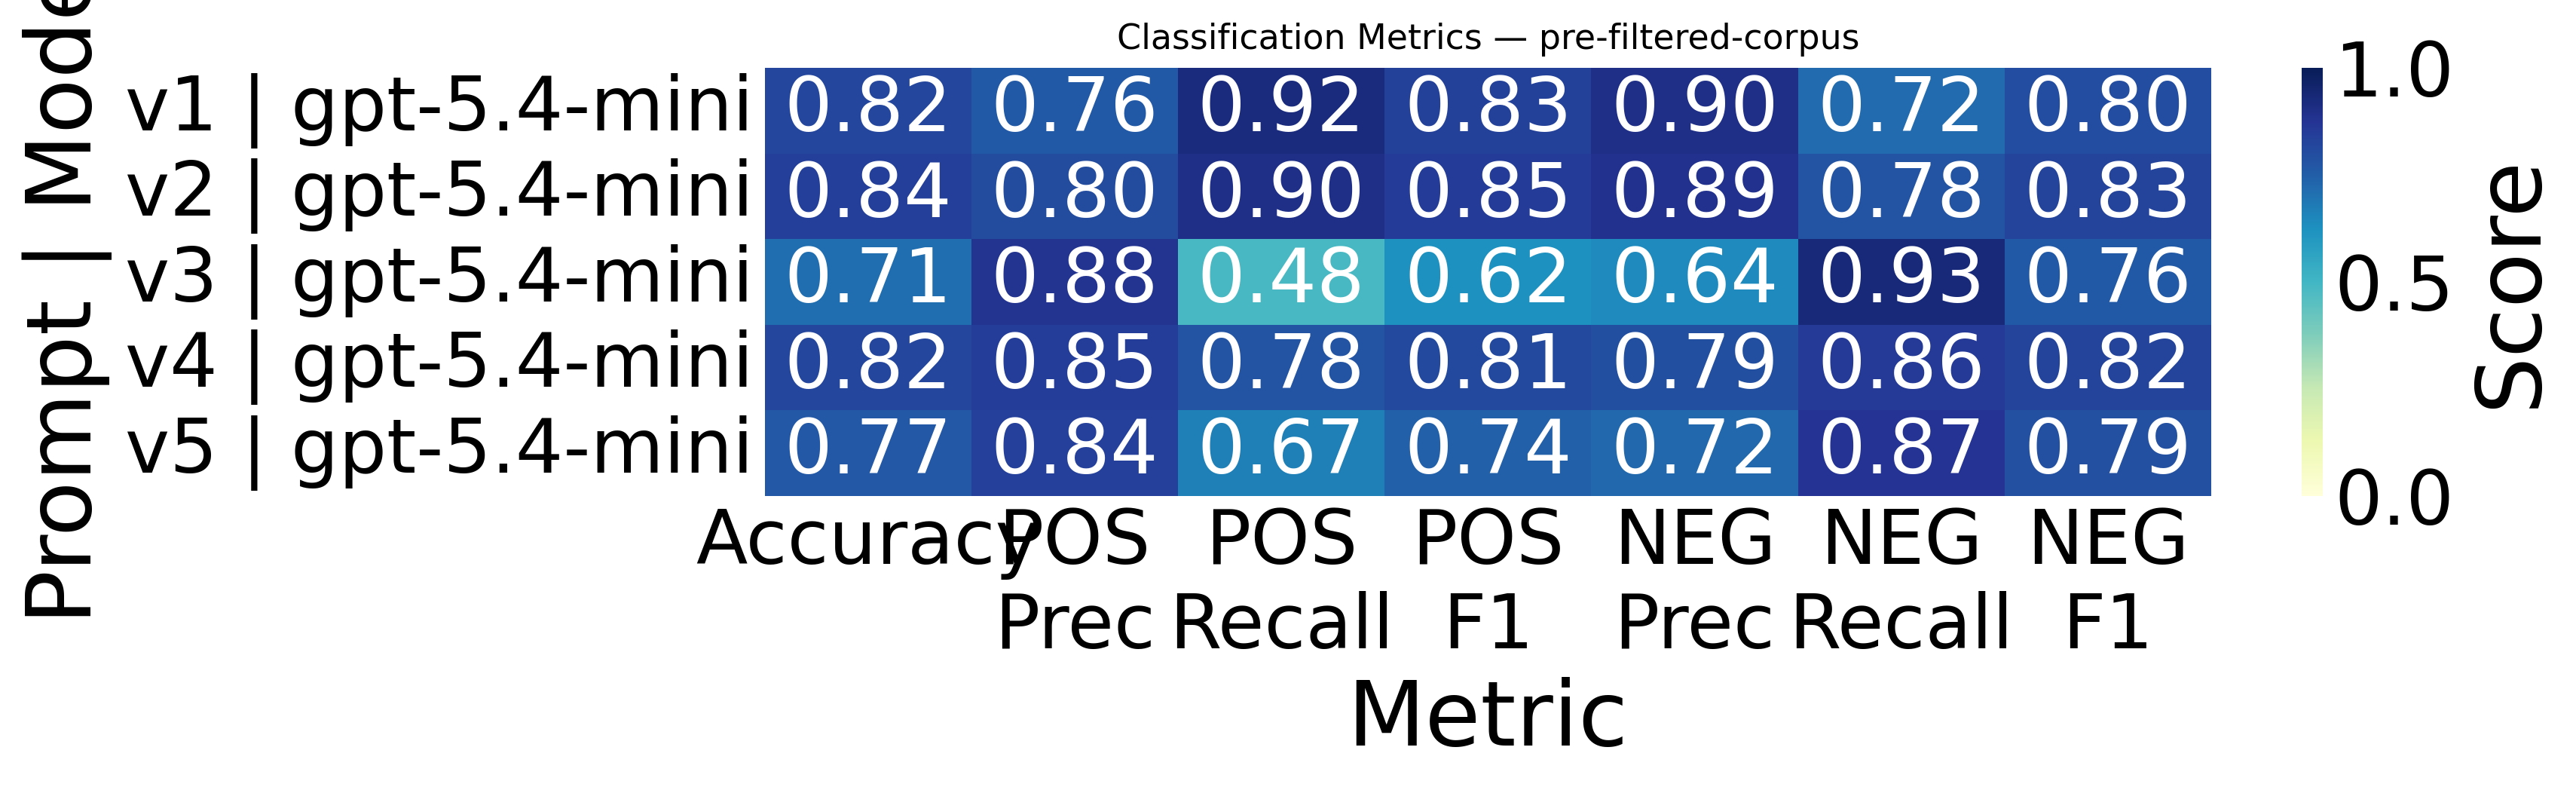

Saved → ../media/results/final-corpus/classification-report-pre-filtered-corpus.png


In [5]:
METRIC_COLS  = ["accuracy", "pos_precision", "pos_recall", "pos_f1",
                "neg_precision", "neg_recall", "neg_f1"]
METRIC_LABELS = ["Accuracy", "POS\nPrec", "POS\nRecall", "POS\nF1",
                 "NEG\nPrec", "NEG\nRecall", "NEG\nF1"]

for corpus_type in CORPUS_TYPES:
    subset = [r for r in all_results if r["corpus"] == corpus_type]
    if not subset:
        print(f"No data yet for {corpus_type}")
        continue

    df = pd.DataFrame(subset).set_index("label")[METRIC_COLS]
    df.columns = METRIC_LABELS

    fig, ax = plt.subplots(figsize=(12, max(3, len(df) * 0.6 + 1)))
    sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".2f",
                cbar_kws={"label": "Score"}, ax=ax, vmin=0, vmax=1)
    ax.set_title(f"Classification Metrics — {corpus_type}", fontsize=11)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Prompt | Model")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="right")
    plt.tight_layout()
    out = f"{OUT_IMG_DIR}/classification-report-{corpus_type}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out}")

## Error heatmap (FP / FN / Total wrong)

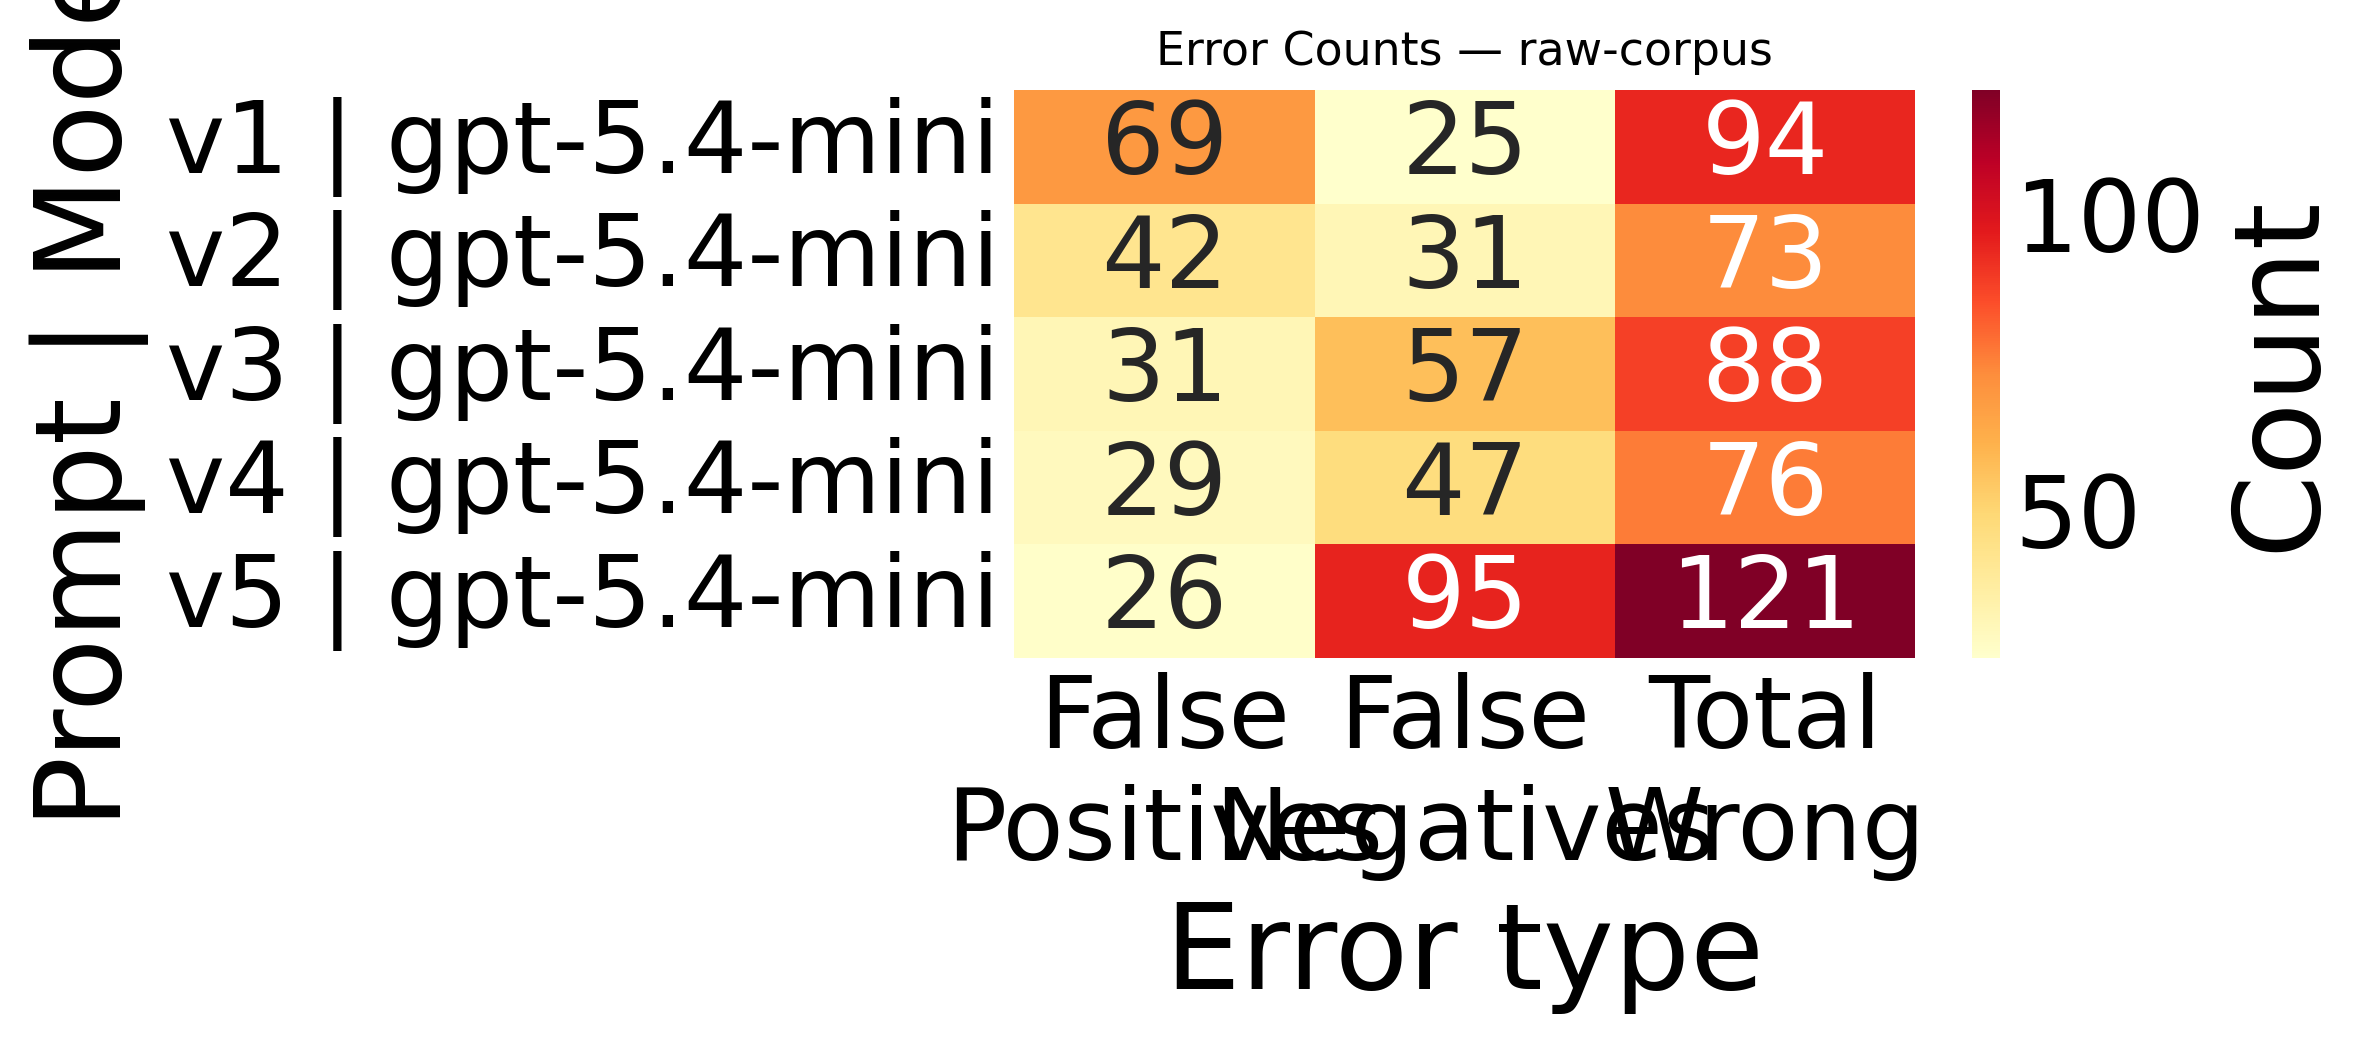

Saved → ../media/results/final-corpus/error-counts-raw-corpus.png


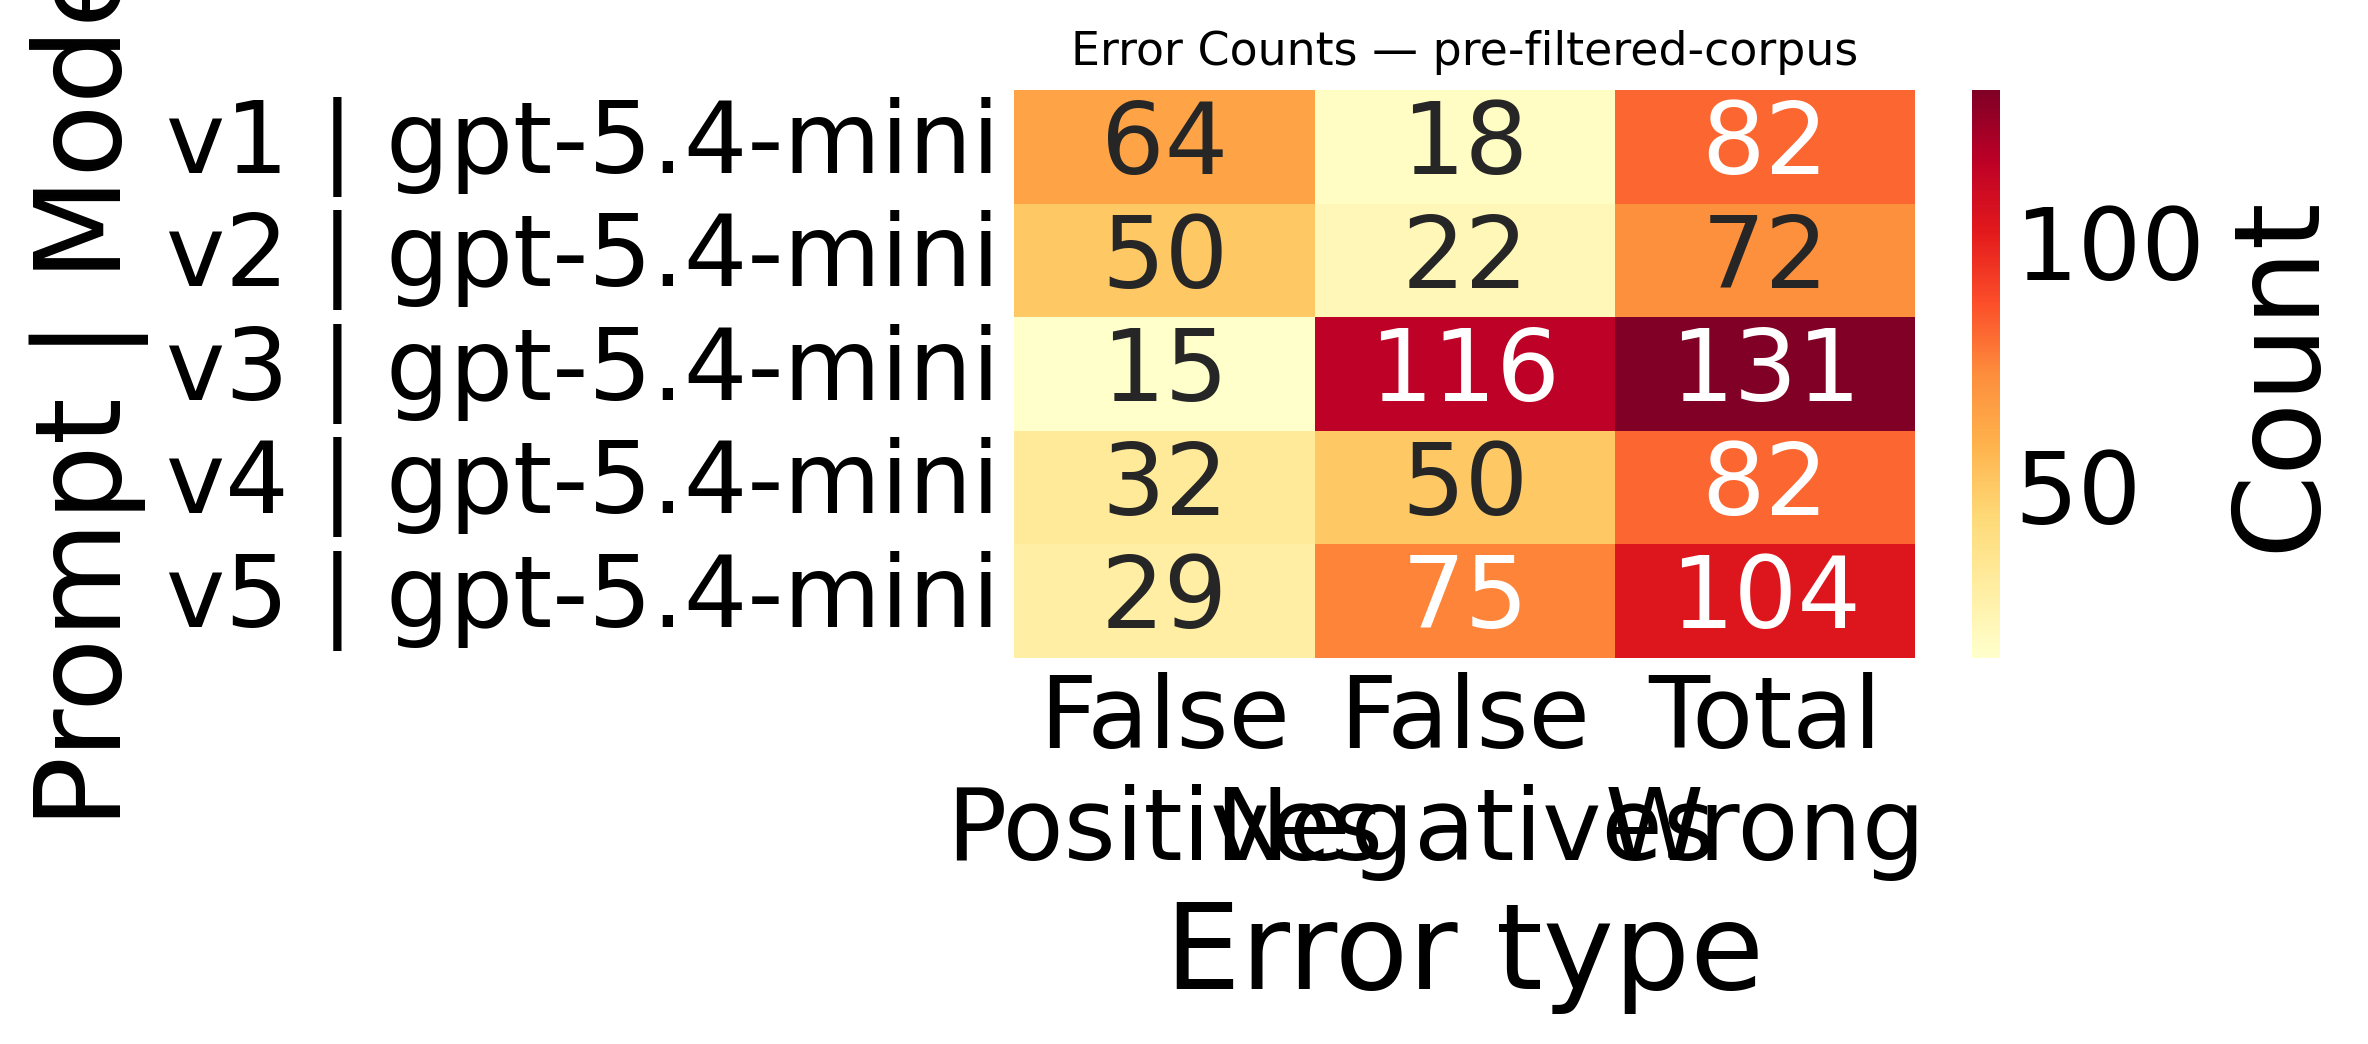

Saved → ../media/results/final-corpus/error-counts-pre-filtered-corpus.png


In [6]:
ERROR_COLS   = ["fp", "fn", "total_wrong"]
ERROR_LABELS = ["False\nPositives", "False\nNegatives", "Total\nWrong"]

for corpus_type in CORPUS_TYPES:
    subset = [r for r in all_results if r["corpus"] == corpus_type]
    if not subset:
        continue

    df = pd.DataFrame(subset).set_index("label")[ERROR_COLS]
    df.columns = ERROR_LABELS

    fig, ax = plt.subplots(figsize=(8, max(3, len(df) * 0.6 + 1)))
    sns.heatmap(df, annot=True, cmap="YlOrRd", fmt="d",
                cbar_kws={"label": "Count"}, ax=ax)
    ax.set_title(f"Error Counts — {corpus_type}", fontsize=11)
    ax.set_xlabel("Error type")
    ax.set_ylabel("Prompt | Model")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="right")
    plt.tight_layout()
    out = f"{OUT_IMG_DIR}/error-counts-{corpus_type}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out}")

## Summary table

In [7]:
if all_results:
    summary = pd.DataFrame(all_results)[[
        "corpus", "model", "version",
        "accuracy", "pos_f1", "neg_f1",
        "fp", "fn", "total_wrong", "n_total"
    ]].sort_values(["corpus", "model", "version"])

    summary = summary.rename(columns={
        "corpus": "Corpus", "model": "Model", "version": "Version",
        "accuracy": "Accuracy", "pos_f1": "POS F1", "neg_f1": "NEG F1",
        "fp": "FP", "fn": "FN", "total_wrong": "Wrong", "n_total": "N",
    })

    display(summary.style.format({
        "Accuracy": "{:.3f}", "POS F1": "{:.3f}", "NEG F1": "{:.3f}",
    }).background_gradient(subset=["Accuracy", "POS F1", "NEG F1"], cmap="YlGnBu"))
else:
    print("No results available yet.")

,Corpus,Model,Version,Accuracy,POS F1,NEG F1,FP,FN,Wrong,N
5,pre-filtered-corpus,gpt-5.4-mini,v1,0.818,0.835,0.797,64,18,82,450
6,pre-filtered-corpus,gpt-5.4-mini,v2,0.840,0.849,0.829,50,22,72,450
7,pre-filtered-corpus,gpt-5.4-mini,v3,0.709,0.625,0.762,15,116,131,450
8,pre-filtered-corpus,gpt-5.4-mini,v4,0.818,0.810,0.825,32,50,82,450
9,pre-filtered-corpus,gpt-5.4-mini,v5,0.769,0.743,0.790,29,75,104,450
0,raw-corpus,gpt-5.4-mini,v1,0.791,0.810,0.768,69,25,94,450
1,raw-corpus,gpt-5.4-mini,v2,0.838,0.842,0.834,42,31,73,450
2,raw-corpus,gpt-5.4-mini,v3,0.804,0.792,0.815,31,57,88,450
3,raw-corpus,gpt-5.4-mini,v4,0.831,0.824,0.838,29,47,76,450
4,raw-corpus,gpt-5.4-mini,v5,0.731,0.682,0.767,26,95,121,450


## Generate FINAL_RESULTS.md

In [8]:
out_file = "../FINAL_RESULTS.md"

def cm_to_html(cm):
    return (
        "<table>"
        "<tr><th></th><th>Pred NEG</th><th>Pred POS</th></tr>"
        f"<tr><th>True NEG</th><td>{cm[1][1]}</td><td>{cm[1][0]}</td></tr>"
        f"<tr><th>True POS</th><td>{cm[0][1]}</td><td>{cm[0][0]}</td></tr>"
        "</table>"
    )

def cr_to_html(r):
    return (
        "<table>"
        "<tr><th>Label</th><th>Prec</th><th>Recall</th><th>F1</th></tr>"
        f"<tr><td>POSITIVE</td><td>{r['pos_precision']:.2f}</td><td>{r['pos_recall']:.2f}</td><td>{r['pos_f1']:.2f}</td></tr>"
        f"<tr><td>NEGATIVE</td><td>{r['neg_precision']:.2f}</td><td>{r['neg_recall']:.2f}</td><td>{r['neg_f1']:.2f}</td></tr>"
        f"<tr><td><b>Accuracy</b></td><td colspan='3'>{r['accuracy']:.2f}</td></tr>"
        "</table>"
    )

with open(out_file, "w", encoding="utf-8") as f:
    f.write("# Final Corpus — Results\n\n")
    f.write("> Auto-generated. Re-run `final_results.ipynb` to refresh.\n\n")

    for corpus_type in CORPUS_TYPES:
        f.write(f"## {corpus_type}\n\n")
        corpus_results = [r for r in all_results if r["corpus"] == corpus_type]

        if not corpus_results:
            f.write("_No results yet._\n\n")
            continue

        for version in VERSIONS:
            version_results = [r for r in corpus_results if r["version"] == version]
            if not version_results:
                continue

            f.write(f"### Prompt {version.upper()}\n\n")
            f.write("```\n" + PROMPTS[version] + "\n```\n\n")
            f.write("| Model | Confusion Matrix | Classification Report | Wrong / Total |\n")
            f.write("|-------|-----------------|----------------------|--------------|\n")
            for r in version_results:
                csv_link = f"[CSV](/data/processed/final-corpus/{r['corpus']}/wct_{r['model']}-{r['version']}.csv)"
                f.write(f"| {r['model']} | {cm_to_html(r['cm'])} | {cr_to_html(r)} | {r['total_wrong']} / {r['n_total']} {csv_link} |\n")
            f.write("\n")

        # corpus-level summary images
        f.write(f"### Summary\n\n")
        f.write(f'<img src="media/results/final-corpus/classification-report-{corpus_type}.png" alt="Classification report — {corpus_type}" />\n\n')
        f.write(f'<img src="media/results/final-corpus/error-counts-{corpus_type}.png" alt="Error counts — {corpus_type}" />\n\n')
        f.write("---\n\n")

print(f"Written → {out_file}")

Written → ../FINAL_RESULTS.md


## Wrongly classified tweets — intersection across runs

Tweets that are consistently misclassified across multiple model/prompt combinations.

In [9]:
error_dfs = []
for corpus_type in CORPUS_TYPES:
    for model in MODELS:
        for version in VERSIONS:
            path = error_csv_path(corpus_type, model, version)
            if os.path.exists(path):
                tmp = pd.read_csv(path)
                tmp["corpus"]  = corpus_type
                tmp["model"]   = model
                tmp["version"] = version
                error_dfs.append(tmp)

if error_dfs:
    all_errors = pd.concat(error_dfs, ignore_index=True)

    # Count how many runs misclassified each tweet (by corpus + text + true label)
    freq = (all_errors.groupby(["corpus", "text", "label"])
                      .size()
                      .reset_index(name="miss_count")
                      .sort_values("miss_count", ascending=False))

    print(f"Unique misclassified tweets across all runs: {len(freq)}")
    print(f"Misclassified in ALL {len(error_dfs)} run(s): {(freq.miss_count == len(error_dfs)).sum()}")
    display(freq.head(30))

    freq.to_csv("../data/processed/final-corpus/unique_wct_final.csv", index=False)
    print("\nSaved → ../data/processed/final-corpus/unique_wct_final.csv")
else:
    print("No error CSVs found yet.")

Unique misclassified tweets across all runs: 399
Misclassified in ALL 10 run(s): 0


,corpus,text,label,miss_count
398,raw-corpus,¿Hoy no se puede consumir? ¿Porque cohartan mi...,NEGATIVE,5
379,raw-corpus,"me gustaría inyectarme heroína, así veo todo r...",NEGATIVE,5
19,pre-filtered-corpus,Cada vez que escucho The Libertines me dan gan...,NEGATIVE,5
369,raw-corpus,como... otro semestre q no podre tomar merca!!!,POSITIVE,5
388,raw-corpus,"tomar merca no te hace alto drogadicto, no voy...",POSITIVE,5
18,pre-filtered-corpus,"Bueno, hay gente que es adicta al paco. Pero q...",POSITIVE,5
5,pre-filtered-corpus,6 cafes me clave hoy. Voy a arrancar inyectarm...,NEGATIVE,5
123,pre-filtered-corpus,Se me ha mojado un porro y he pensado en meter...,POSITIVE,5
314,raw-corpus,No tendría que hacer lo que hicieron mis ídolo...,POSITIVE,5
316,raw-corpus,Nose si tomarme una línea o que me choque una ...,POSITIVE,5



Saved → ../data/processed/final-corpus/unique_wct_final.csv
